In [1]:
print("TP ML OK")

TP ML OK


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

df = X.copy()
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
print("Taille :", df.shape)
print(df.head())

Taille : (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [5]:
X_simple = df[["bmi"]]
y_simple = df["target"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_simple = model_simple.predict(X_test_s)

print("R2 simple:", r2_score(y_test_s, y_pred_simple))

R2 simple: 0.23335039815872138


In [6]:
X_simple = df[["bmi"]]
y_simple = df["target"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_simple = model_simple.predict(X_test_s)

print("R2 simple:", r2_score(y_test_s, y_pred_simple))

R2 simple: 0.23335039815872138


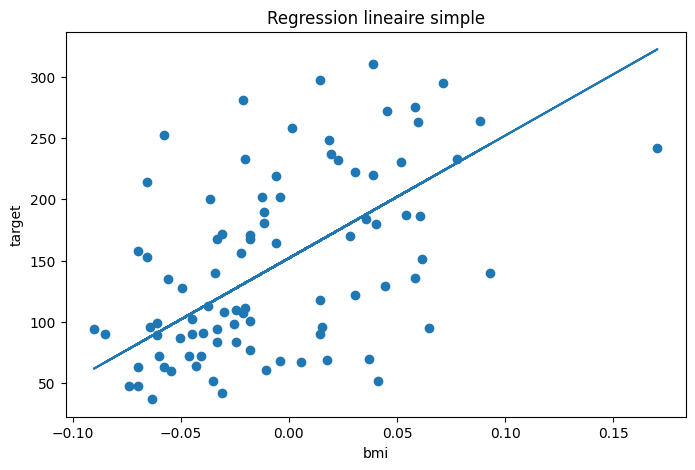

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(X_test_s, y_test_s)
plt.plot(X_test_s, y_pred_simple)
plt.title("Regression lineaire simple")
plt.xlabel("bmi")
plt.ylabel("target")
plt.savefig("graphe_regression_simple.png")
plt.show()

In [8]:
X_multiple = df.drop(columns=["target"])
y_multiple = df["target"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)

y_pred_multiple = model_multiple.predict(X_test_m)

print("R2 multiple:", r2_score(y_test_m, y_pred_multiple))

R2 multiple: 0.4526027629719196


In [9]:
poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X_simple)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_simple, test_size=0.2, random_state=42
)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

y_pred_poly = model_poly.predict(X_test_p)

print("R2 polynomial:", r2_score(y_test_p, y_pred_poly))

R2 polynomial: 0.23285636640090268


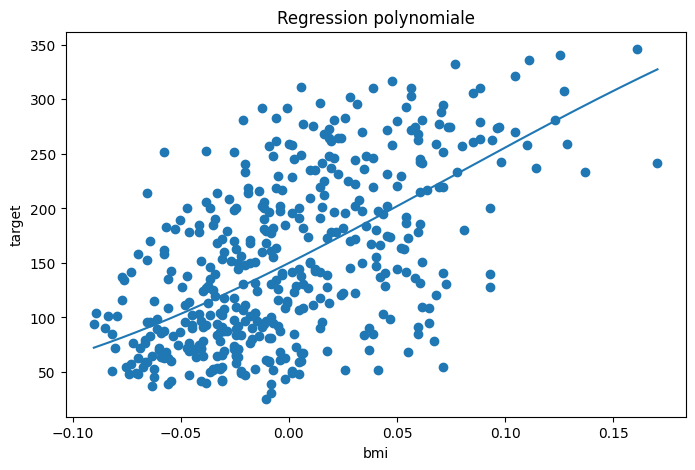

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(X_simple, y_simple)
plt.plot(X_curve, y_curve)
plt.title("Regression polynomiale")
plt.xlabel("bmi")
plt.ylabel("target")
plt.savefig("graphe_regression_polynomiale.png")
plt.show()

In [11]:
results = pd.DataFrame({
    "Modele": ["Simple", "Multiple", "Polynomial"],
    "R2": [
        r2_score(y_test_s, y_pred_simple),
        r2_score(y_test_m, y_pred_multiple),
        r2_score(y_test_p, y_pred_poly)
    ]
})

results

,Modele,R2
0,Simple,0.233350
1,Multiple,0.452603
2,Polynomial,0.232856


In [12]:
df.to_csv("dataset_diabetes.csv", index=False)

In [15]:
from mpl_toolkits.mplot3d import Axes3D

In [16]:
X_vis = df[["bmi", "bp"]]
y_vis = df["target"]

model_vis = LinearRegression()
model_vis.fit(X_vis, y_vis)

print("Coefficients :", model_vis.coef_)
print("Intercept :", model_vis.intercept_)

Coefficients : [790.39861084 402.20603444]
Intercept : 152.13348416289614


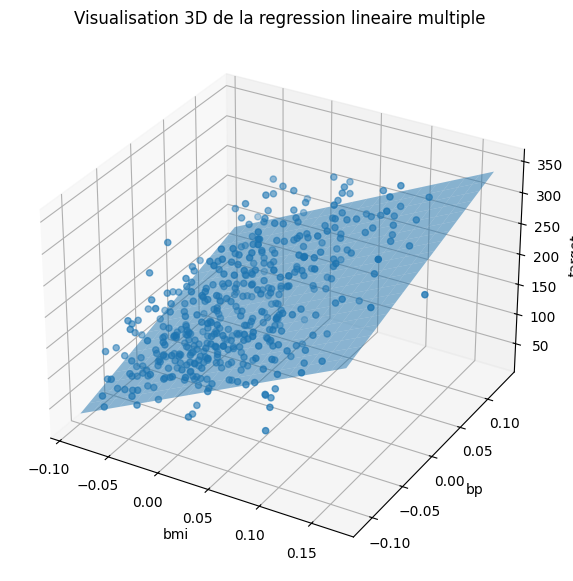

In [17]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Points réels
ax.scatter(X_vis["bmi"], X_vis["bp"], y_vis)

# Création du plan de régression
x_range = np.linspace(X_vis["bmi"].min(), X_vis["bmi"].max(), 20)
y_range = np.linspace(X_vis["bp"].min(), X_vis["bp"].max(), 20)

xx, yy = np.meshgrid(x_range, y_range)
z = model_vis.intercept_ + model_vis.coef_[0] * xx + model_vis.coef_[1] * yy

ax.plot_surface(xx, yy, z, alpha=0.5)

ax.set_xlabel("bmi")
ax.set_ylabel("bp")
ax.set_zlabel("target")
ax.set_title("Visualisation 3D de la regression lineaire multiple")

plt.savefig("graphe_regression_multiple_3D.png")
plt.show()

In [1]:
# Importation des bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Chargement du dataset
from sklearn.datasets import load_diabetes

# Séparation des données en ensemble d'entraînement et de test
from sklearn.model_selection import train_test_split

# Modèles de régression
from sklearn.linear_model import LinearRegression, LogisticRegression

# Transformation polynomiale
from sklearn.preprocessing import PolynomialFeatures

# Métriques d'évaluation
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Bibliothèque pour la visualisation 3D
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Chargement du dataset diabetes depuis scikit-learn
diabetes = load_diabetes()

# Création d'un DataFrame contenant les variables explicatives
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Création de la variable cible
y = pd.Series(diabetes.target, name="target")

# Création d'un DataFrame complet contenant X et y
df = X.copy()
df["target"] = y

# Affichage des 5 premières lignes
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Affichage de la taille du dataset
print("Taille du dataset :", df.shape)

# Affichage des premières lignes
print(df.head())

Taille du dataset : (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [4]:
# -------------------------------
# Régression linéaire simple
# -------------------------------
# On choisit une seule variable explicative : bmi
X_simple = df[["bmi"]]
y_simple = df["target"]

# Séparation en données d'entraînement et de test
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Création du modèle
model_simple = LinearRegression()

# Entraînement du modèle
model_simple.fit(X_train_s, y_train_s)

# Prédiction sur les données de test
y_pred_simple = model_simple.predict(X_test_s)

# Évaluation du modèle
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

# Affichage des résultats
print("Régression linéaire simple")
print("Coefficient :", model_simple.coef_[0])
print("Intercept :", model_simple.intercept_)
print("MSE :", mse_simple)
print("R2 :", r2_simple)

Régression linéaire simple
Coefficient : 998.5776891375593
Intercept : 152.00335421448167
MSE : 4061.8259284949268
R2 : 0.23335039815872138


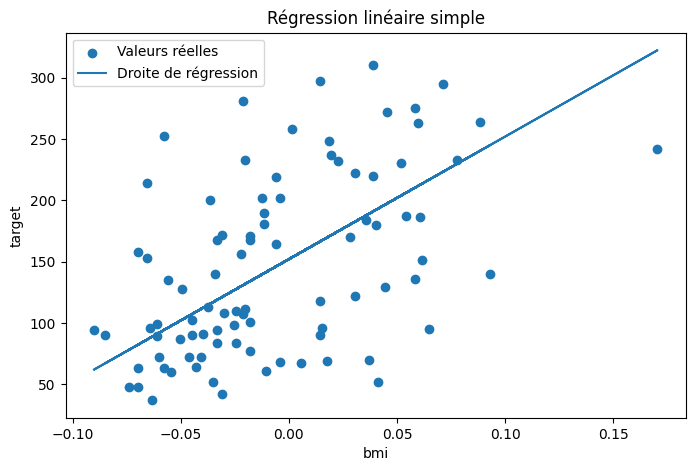

In [5]:
# Visualisation des données réelles et de la droite de régression
plt.figure(figsize=(8,5))
plt.scatter(X_test_s, y_test_s, label="Valeurs réelles")
plt.plot(X_test_s, y_pred_simple, label="Droite de régression")
plt.title("Régression linéaire simple")
plt.xlabel("bmi")
plt.ylabel("target")
plt.legend()
plt.savefig("graphe_regression_simple.png")
plt.show()

In [6]:
# -------------------------------
# Régression linéaire multiple
# -------------------------------
# On utilise toutes les variables explicatives du dataset
X_multiple = df.drop(columns=["target"])
y_multiple = df["target"]

# Séparation des données
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Création du modèle
model_multiple = LinearRegression()

# Entraînement
model_multiple.fit(X_train_m, y_train_m)

# Prédiction
y_pred_multiple = model_multiple.predict(X_test_m)

# Évaluation
mse_multiple = mean_squared_error(y_test_m, y_pred_multiple)
r2_multiple = r2_score(y_test_m, y_pred_multiple)

# Résultats
print("Régression linéaire multiple")
print("MSE :", mse_multiple)
print("R2 :", r2_multiple)

Régression linéaire multiple
MSE : 2900.1936284934804
R2 : 0.4526027629719196


In [7]:
# -------------------------------
# Régression polynomiale
# -------------------------------
# On applique une transformation polynomiale de degré 3
# sur la variable bmi

poly = PolynomialFeatures(degree=3)

# Transformation de la variable d'entrée
X_poly = poly.fit_transform(X_simple)

# Séparation des données
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_simple, test_size=0.2, random_state=42
)

# Création du modèle
model_poly = LinearRegression()

# Entraînement
model_poly.fit(X_train_p, y_train_p)

# Prédiction
y_pred_poly = model_poly.predict(X_test_p)

# Évaluation
mse_poly = mean_squared_error(y_test_p, y_pred_poly)
r2_poly = r2_score(y_test_p, y_pred_poly)

# Résultats
print("Régression polynomiale (degré 3)")
print("MSE :", mse_poly)
print("R2 :", r2_poly)

Régression polynomiale (degré 3)
MSE : 4064.4433837164365
R2 : 0.23285636640090268


c:\Users\pc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


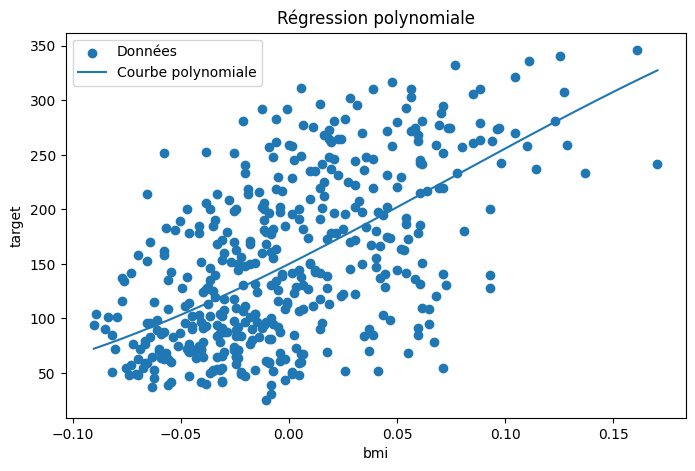

In [8]:
# Création d'une courbe lisse pour visualiser la régression polynomiale
X_curve = np.linspace(X_simple.min().values[0], X_simple.max().values[0], 200).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)
y_curve = model_poly.predict(X_curve_poly)

# Affichage des points et de la courbe
plt.figure(figsize=(8,5))
plt.scatter(X_simple, y_simple, label="Données")
plt.plot(X_curve, y_curve, label="Courbe polynomiale")
plt.title("Régression polynomiale")
plt.xlabel("bmi")
plt.ylabel("target")
plt.legend()
plt.savefig("graphe_regression_polynomiale.png")
plt.show()

In [9]:
# -------------------------------
# Régression logistique
# -------------------------------
# La régression logistique nécessite une variable cible binaire.
# On transforme donc la variable target en 2 classes :
# 0 si la valeur est inférieure ou égale à la médiane
# 1 si la valeur est supérieure à la médiane

y_log = (df["target"] > df["target"].median()).astype(int)

# Variables explicatives
X_log = df.drop(columns=["target"])

# Séparation des données en apprentissage et test
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# Création du modèle logistique
model_log = LogisticRegression(max_iter=2000, solver="liblinear")

# Entraînement du modèle
model_log.fit(X_train_l, y_train_l)

# Prédiction
y_pred_log = model_log.predict(X_test_l)

# Évaluation
acc_log = accuracy_score(y_test_l, y_pred_log)

print("Régression logistique")
print("Accuracy :", acc_log)
print("\nMatrice de confusion :")
print(confusion_matrix(y_test_l, y_pred_log))
print("\nRapport de classification :")
print(classification_report(y_test_l, y_pred_log))

Régression logistique
Accuracy : 0.7415730337078652

Matrice de confusion :
[[37 12]
 [11 29]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.77      0.76      0.76        49
           1       0.71      0.72      0.72        40

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



In [10]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

In [11]:
y_log = (df["target"] > df["target"].median()).astype(int)
X_log = df.drop(columns=["target"])

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

model_log = LogisticRegression(max_iter=2000, solver="liblinear")
model_log.fit(X_train_l, y_train_l)

y_pred_log = model_log.predict(X_test_l)

print("Accuracy :", accuracy_score(y_test_l, y_pred_log))

Accuracy : 0.7415730337078652
